In [1]:
from datasets.cross_tissue_atlas import CrossTissueDataset
import os

import hydra
from omegaconf import OmegaConf

import torch
import numpy as np

from geomloss import SamplesLoss

/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
train_set = CrossTissueDataset(
    root="data",
    split="train",
)

test_set = CrossTissueDataset(
    root="data",
    split="test",
    set_size=512
)

In [3]:
adata = test_set.adata

In [4]:
train_donors = train_set.donors
test_donors = test_set.donors
print(train_donors)
print(test_donors)

['GTEX-12BJ1', 'GTEX-13N11', 'GTEX-144GM', 'GTEX-145ME', 'GTEX-15CHR', 'GTEX-15EOM', 'GTEX-15RIE', 'GTEX-15SB6']
['GTEX-16BQI', 'GTEX-1CAMR', 'GTEX-1CAMS', 'GTEX-1HSMQ', 'GTEX-1I1GU', 'GTEX-1ICG6', 'GTEX-1MCC2', 'GTEX-1R9PN']


In [5]:
donor_centroids = {}
for donor in test_donors:
    donor_data = test_set.adata[test_set.adata.obs['donor_id'] == donor]
    centroid = np.nan_to_num(donor_data.obsm['X_pca']).mean(axis=0).flatten()
    donor_centroids[donor] = centroid
for donor in train_donors:
    donor_data = train_set.adata[train_set.adata.obs['donor_id'] == donor]
    centroid = np.nan_to_num(donor_data.obsm['X_pca']).mean(axis=0).flatten()
    donor_centroids[donor] = centroid

# for each test donor, get the nearest train donor
test_to_train_donor = {}
for test_donor in test_donors:
    test_centroid = donor_centroids[test_donor]
    nearest_train_donor = None
    nearest_distance = float('inf')
    for train_donor in train_donors:
        train_centroid = donor_centroids[train_donor]
        distance = torch.norm(torch.tensor(test_centroid) - torch.tensor(train_centroid)).item()
        if distance < nearest_distance:
            nearest_distance = distance
            nearest_train_donor = train_donor
    test_to_train_donor[test_donor] = nearest_train_donor

print("Test to Train Donor Mapping:")
for test_donor, train_donor in test_to_train_donor.items():
    print(f"{test_donor} -> {train_donor}")

Test to Train Donor Mapping:
GTEX-16BQI -> GTEX-15SB6
GTEX-1CAMR -> GTEX-13N11
GTEX-1CAMS -> GTEX-15EOM
GTEX-1HSMQ -> GTEX-13N11
GTEX-1I1GU -> GTEX-12BJ1
GTEX-1ICG6 -> GTEX-13N11
GTEX-1MCC2 -> GTEX-15EOM
GTEX-1R9PN -> GTEX-13N11


In [6]:
output_dir = '/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/outputs/'

configs = os.listdir(output_dir)

config_name = [x for x in configs if x.startswith('crosstissue_gnn_energy_')][0]
print(config_name)
config_path = os.path.join(output_dir, config_name, 'config.yaml')
if not os.path.exists(config_path):
    raise FileNotFoundError(f"Config not found at {config_path}")

config = OmegaConf.load(config_path)

best_model_path = os.path.join(output_dir, config_name, 'best_model.pt')
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Best model not found at {best_model_path}")

dct_encoder = hydra.utils.instantiate(config.encoder)
dct_generator = hydra.utils.instantiate(config.generator)

device = 'cuda'
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)

dct_encoder.load_state_dict(checkpoint['encoder_state_dict'])
dct_generator.load_state_dict(checkpoint['generator_state_dict'])

epoch = checkpoint.get('epoch', 'unknown')
loss = checkpoint.get('loss', float('nan'))

dct_encoder.to(device)
dct_generator.to(device)
dct_encoder.eval()
dct_generator.eval();

crosstissue_gnn_energy_a0461089364e592ec6d81805f7ff3038


In [7]:
energy = SamplesLoss("energy")

energy_dists = []

for p in range(8):

    for _ in range(100):

        batch = test_set[p]

        source_samples = batch['source_samples'].to(device).unsqueeze(0)
        target_samples = batch['target_samples'].to(device).unsqueeze(0)

        with torch.no_grad():
            source_latent = dct_encoder(source_samples)
            target_latent = dct_encoder(target_samples)

            # print(source_latent.shape)

            samples = dct_generator.sample(source_samples.reshape(-1, 50), source_latent, target_latent)

        e_dist = energy(samples.squeeze(0), target_samples.squeeze(0)).item()
        energy_dists.append(e_dist)

print("mean Energy Distance:", np.mean(energy_dists))
print('s.e.m', np.std(energy_dists) / np.sqrt(len(energy_dists)))

mean Energy Distance: 0.8486367517709732
s.e.m 0.019183618438223183


In [8]:
output_dir = '/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/outputs/'

configs = os.listdir(output_dir)

config_name = [x for x in configs if x.startswith('crosstissue_onehot_energy_')][0]
print(config_name)
config_path = os.path.join(output_dir, config_name, 'config.yaml')
if not os.path.exists(config_path):
    raise FileNotFoundError(f"Config not found at {config_path}")

config = OmegaConf.load(config_path)

# Detect model types
encoder_type, generator_type = ('esm', 'progen2')

best_model_path = os.path.join(output_dir, config_name, 'best_model.pt')
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Best model not found at {best_model_path}")

onehot_encoder = hydra.utils.instantiate(config.encoder)
onehot_generator = hydra.utils.instantiate(config.generator)

device = 'cuda'
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)

onehot_encoder.load_state_dict(checkpoint['encoder_state_dict'])
onehot_generator.load_state_dict(checkpoint['generator_state_dict'])

epoch = checkpoint.get('epoch', 'unknown')
loss = checkpoint.get('loss', float('nan'))

print(epoch, loss)

onehot_encoder.to(device)
onehot_generator.to(device)
onehot_encoder.eval()
onehot_generator.eval();

crosstissue_onehot_energy_72d66fad894ab5988deff2e8a63d3adf
4800 3.9537558555603027


In [9]:
energy = SamplesLoss("energy")

energy_dists = []

for p in range(8):

    for _ in range(100):

        batch = test_set[p]

        source_samples = batch['source_samples'].to(device).unsqueeze(0)
        target_samples = batch['target_samples'].to(device).unsqueeze(0)

        source_donor = batch['source_metadata']['donor_id']
        target_donor = batch['target_metadata']['donor_id']

        nearest_source_donor = test_to_train_donor[source_donor]
        nearest_target_donor = test_to_train_donor[target_donor]

        nn_source_idx = torch.tensor(train_set.donors.index(nearest_source_donor)).cuda()
        nn_target_idx = torch.tensor(train_set.donors.index(nearest_target_donor)).cuda()

        with torch.no_grad():
            source_latent = onehot_encoder(nn_source_idx).repeat(source_samples.shape[0], 1)
            target_latent = onehot_encoder(nn_target_idx).repeat(target_samples.shape[0], 1)

            # print(source_latent.shape)

            samples = onehot_generator.sample(source_samples.reshape(-1, 50), source_latent, target_latent)

        e_dist = energy(samples.squeeze(0), target_samples.squeeze(0)).item()
        energy_dists.append(e_dist)

print("mean Energy Distance:", np.mean(energy_dists))
print('s.e.m', np.std(energy_dists) / np.sqrt(len(energy_dists)))

mean Energy Distance: 1.0330823308229446
s.e.m 0.022743332712649618


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

DCT E Dist: 0.32656288146972656
OneHot E Dist: 0.48685646057128906
DCT E Dist: 0.35243701934814453
OneHot E Dist: 0.462432861328125
DCT E Dist: 0.3074207305908203
OneHot E Dist: 0.4154043197631836
DCT E Dist: 0.23302078247070312
OneHot E Dist: 0.38724517822265625
DCT E Dist: 0.3148994445800781
OneHot E Dist: 0.42659473419189453
DCT E Dist: 0.22779464721679688
OneHot E Dist: 0.36960887908935547
DCT E Dist: 0.3485383987426758
OneHot E Dist: 0.42745399475097656
DCT E Dist: 0.3118600845336914
OneHot E Dist: 0.42118072509765625


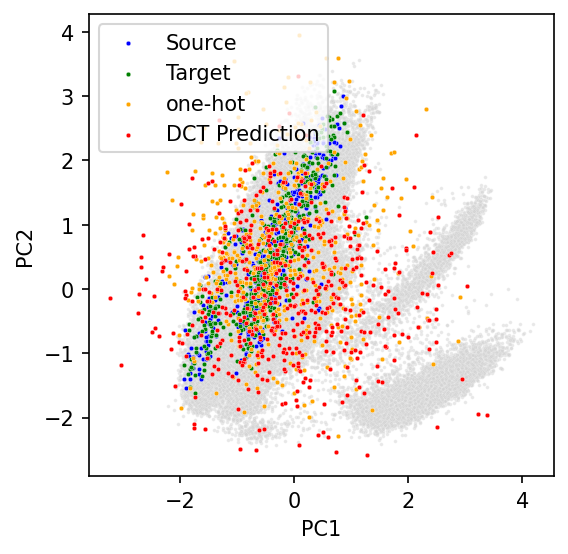

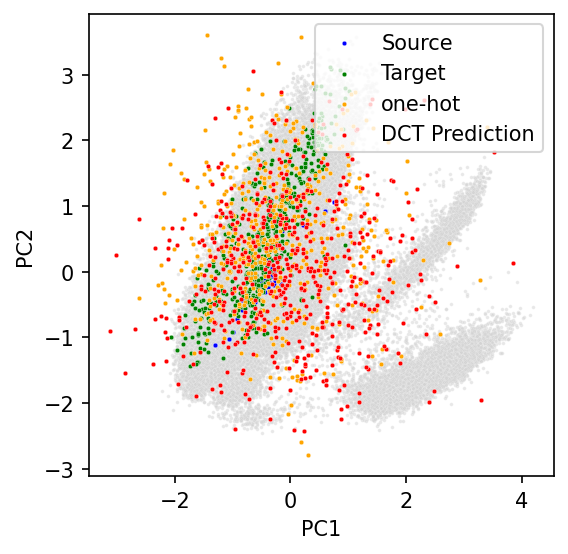

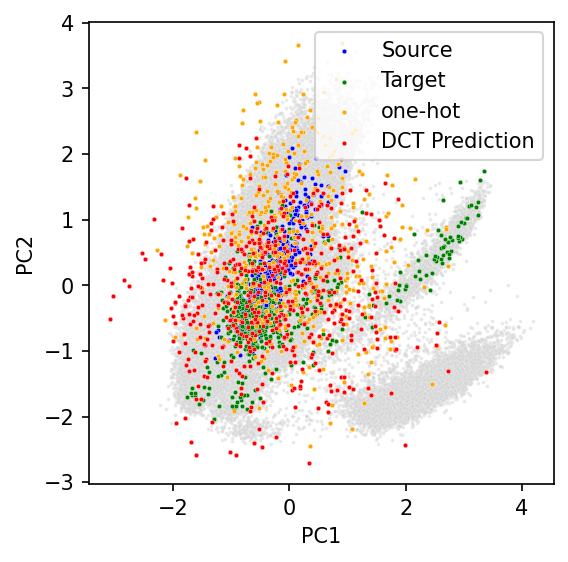

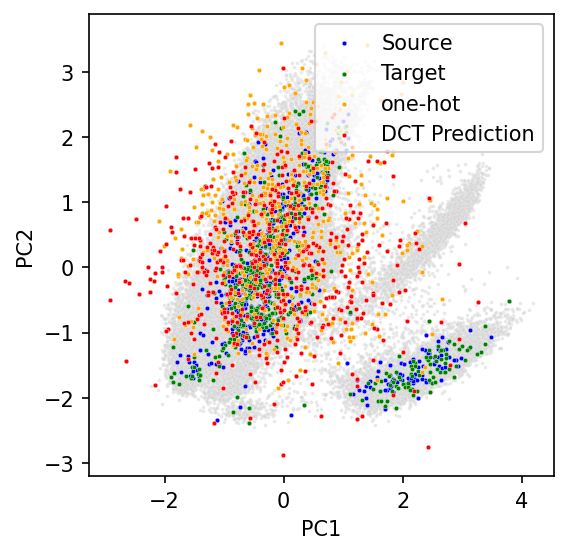

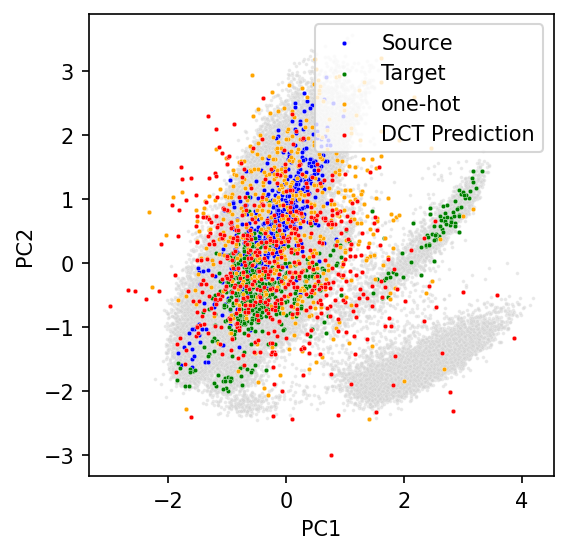

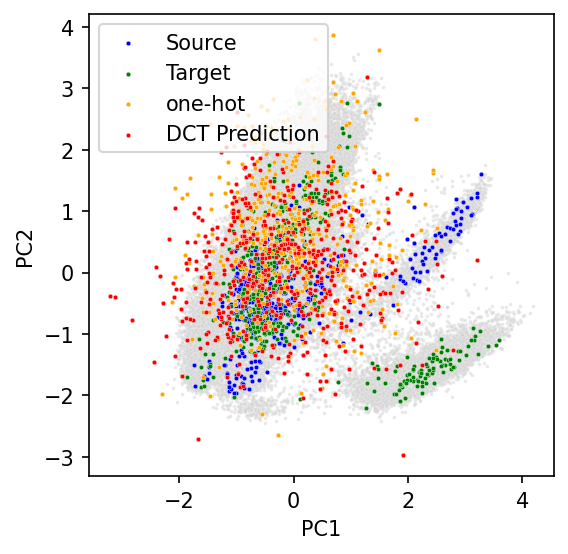

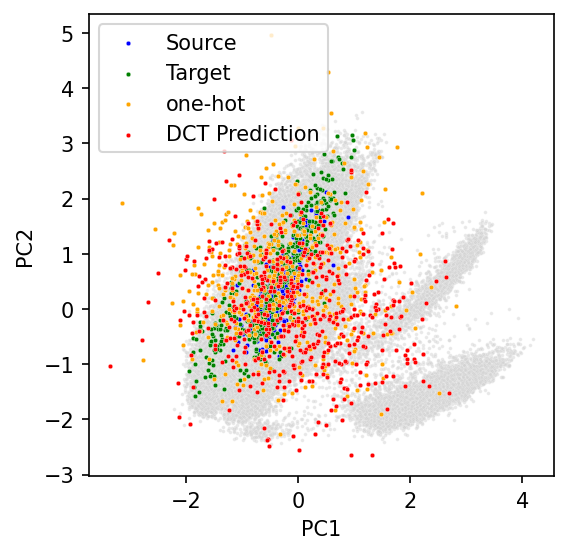

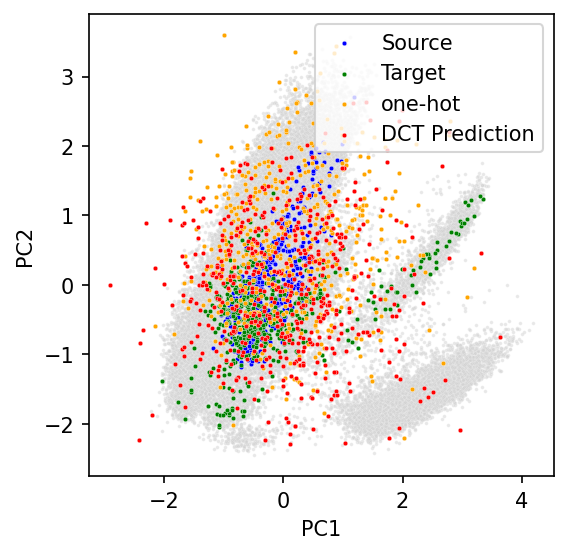

In [19]:
for i in range(8):

    for _ in range(10):

        batch = test_set[i]

        source_samples = batch['source_samples'].to(device).unsqueeze(0)
        target_samples = batch['target_samples'].to(device).unsqueeze(0)

        source_donor = batch['source_metadata']['donor_id']
        target_donor = batch['target_metadata']['donor_id']

        nearest_source_donor = test_to_train_donor[source_donor]
        nearest_target_donor = test_to_train_donor[target_donor]

        nn_source_idx = torch.tensor(train_set.donors.index(nearest_source_donor)).cuda()
        nn_target_idx = torch.tensor(train_set.donors.index(nearest_target_donor)).cuda()

        # get predictions for onehot and dct models, then plot first two pcs
        with torch.no_grad():
            onehot_source_latent = onehot_encoder(nn_source_idx).repeat(source_samples.shape[0], 1)
            onehot_target_latent = onehot_encoder(nn_target_idx).repeat(target_samples.shape[0], 1)

            onehot_samples = onehot_generator.sample(source_samples.reshape(-1, 50), onehot_source_latent, onehot_target_latent)

            dct_source_latent = dct_encoder(source_samples)
            dct_target_latent = dct_encoder(target_samples)

            dct_samples = dct_generator.sample(source_samples.reshape(-1, 50), dct_source_latent, dct_target_latent)

        onehot_samples = onehot_samples.squeeze(0).cpu().numpy()
        dct_samples = dct_samples.squeeze(0).cpu().numpy()
        target_samples = target_samples.squeeze(0).cpu().numpy()
        source_samples = source_samples.squeeze(0).cpu().numpy()

        # get energy distances for both models
        onehot_e_dist = energy(torch.tensor(onehot_samples), torch.tensor(target_samples)).item()
        dct_e_dist = energy(torch.tensor(dct_samples), torch.tensor(target_samples)).item()

        # if the e_dist for dct is lower, then plot and break

        if dct_e_dist < 0.5:
            print("DCT E Dist:", dct_e_dist)
            print("OneHot E Dist:", onehot_e_dist)

            # first plot all points in pca space, light grey

            plt.figure(figsize=(4, 4), dpi=150)
            sns.scatterplot(x=adata.obsm['X_pca'][:, 0], y=adata.obsm['X_pca'][:, 1], 
                            color='lightgrey', alpha=0.5, s=3)
            # plot source samples in blue
            sns.scatterplot(x=source_samples[:, 0], y=source_samples[:, 1], 
                            color='blue', label='Source', s=5)
            # plot target samples in green
            sns.scatterplot(x=target_samples[:, 0], y=target_samples[:, 1], 
                            color='green', label='Target', s=5)
            # plot onehot samples in orange
            sns.scatterplot(x=onehot_samples[:, 0], y=onehot_samples[:, 1], 
                            color='orange', label='one-hot', s=5)
            # plot dct samples in red
            sns.scatterplot(x=dct_samples[:, 0], y=dct_samples[:, 1], 
                            color='red', label='DCT Prediction', s=5)
            
            plt.ylabel('PC2')
            plt.xlabel('PC1')
            break